<a href="https://colab.research.google.com/github/KhushiJ2911/Predictive-Maintenance-PDM-of-Diesel-Engine/blob/main/Fault5_RUL_EGR_Updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [ ]:
DATA_PATH = "/content/Problem5_FAULT_TimeSeries_20251222_012347.csv"

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(171943, 9)


,TimeHour,ProblemID,RunID,RPM,FaultMetric,DamageRate,Damage,RUL_hours,FaultFlag
0,0,5,1,1500.390022,0.780286,0.000008,0.002757,9999.997243,1
1,1,5,1,2237.473144,1.100851,0.000017,0.004826,9999.995174,1
2,2,5,1,2792.211748,1.461075,0.000029,0.008253,9999.991747,1
3,3,5,1,3027.370917,1.858229,0.000039,0.012978,9999.987022,1
4,4,5,1,2884.775413,2.290147,0.000046,0.018528,9999.981472,1


In [ ]:
FEATURES = [
    "RPM",
    "FaultMetric",
    "DamageRate",
    "Damage"
]

df["RUL_norm"] = (
    df["RUL_hours"] /
    df.groupby("RunID")["RUL_hours"].transform("max")
)


In [ ]:
df = df[FEATURES + ["RUL_norm", "RunID"]]

df = df.fillna(method="ffill")
df = df.fillna(method="bfill")
df = df.dropna()

assert df.isna().sum().sum() == 0


/tmp/ipython-input-2003247251.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")
/tmp/ipython-input-2003247251.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="bfill")


In [ ]:
run_ids = df["RunID"].unique()
np.random.shuffle(run_ids)

train_runs = run_ids[:int(0.8 * len(run_ids))]
test_runs  = run_ids[int(0.8 * len(run_ids)):]

train_df = df[df["RunID"].isin(train_runs)]
test_df  = df[df["RunID"].isin(test_runs)]

print("Train runs:", len(train_runs))
print("Test runs:", len(test_runs))


Train runs: 80
Test runs: 20


In [ ]:
X_scaler = MinMaxScaler()

X_train = X_scaler.fit_transform(train_df[FEATURES])
X_test  = X_scaler.transform(test_df[FEATURES])

y_train = train_df[["RUL_norm"]].values
y_test  = test_df[["RUL_norm"]].values


In [ ]:
def create_sequences(X, y, seq_len=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len])
    return np.array(X_seq), np.array(y_seq)

SEQ_LEN = 30

X_train_seq, y_train_seq = create_sequences(X_train, y_train, SEQ_LEN)
X_test_seq,  y_test_seq  = create_sequences(X_test, y_test, SEQ_LEN)

print(X_train_seq.shape, X_test_seq.shape)


(137052, 30, 4) (34831, 30, 4)


In [ ]:
MODEL_DIR = "/content/drive/MyDrive/RUL_Models/Fault5_LSTM"
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH = MODEL_DIR + "/best_model.keras"


In [ ]:
model = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(16, activation="relu"),
    Dense(1, activation="linear")
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath=MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


In [ ]:
history = model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop, checkpoint],
    verbose=1
)


Epoch 1/50
1712/1714 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0168 - mae: 0.0440
Epoch 1: val_loss improved from inf to 0.00064, saving model to /content/drive/MyDrive/RUL_Models/Fault5_LSTM/best_model.keras
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 0.0168 - mae: 0.0440 - val_loss: 6.3944e-04 - val_mae: 0.0067
Epoch 2/50
1712/1714 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.4579e-04 - mae: 0.0076
Epoch 2: val_loss improved from 0.00064 to 0.00054, saving model to /content/drive/MyDrive/RUL_Models/Fault5_LSTM/best_model.keras
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5.4590e-04 - mae: 0.0076 - val_loss: 5.3825e-04 - val_mae: 0.0054
Epoch 3/50
1713/1714 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.8957e-04 - mae: 0.0073
Epoch 3: val_loss did not improve from 0.00054
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5.8954e-04 - mae: 0.0073 - val_loss: 5.7779e-04 - val_mae: 0.0058
Epoch 4/50
1713/1714 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.5017e-04 - mae: 0.0062
E

In [ ]:
model = load_model(MODEL_PATH)


In [ ]:
y_pred = model.predict(X_test_seq)

mae_norm = mean_absolute_error(y_test_seq, y_pred)
rmse_norm = np.sqrt(mean_squared_error(y_test_seq, y_pred))
r2 = r2_score(y_test_seq, y_pred)

print("MAE (normalized):", mae_norm)
print("RMSE (normalized):", rmse_norm)
print("R²:", r2)


1089/1089 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step
MAE (normalized): 0.0017704559777957784
RMSE (normalized): 0.02137945554268012
R²: 0.9937550769335689


In [ ]:
avg_life_hours = (
    pd.read_csv(DATA_PATH)
    .groupby("RunID")["RUL_hours"]
    .max()
    .mean()
)

print("Approx MAE (hours):", mae_norm * avg_life_hours)
print("Approx RMSE (hours):", rmse_norm * avg_life_hours)


Approx MAE (hours): 17.704554800834234
Approx RMSE (hours): 213.79449532466202


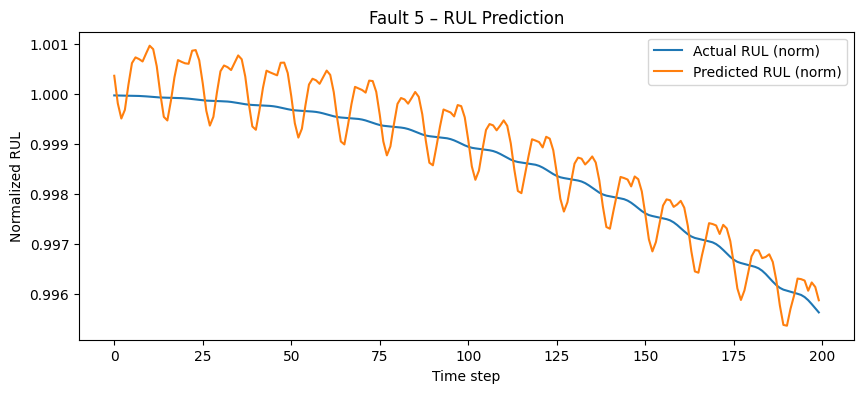

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y_test_seq[:200], label="Actual RUL (norm)")
plt.plot(y_pred[:200], label="Predicted RUL (norm)")
plt.xlabel("Time step")
plt.ylabel("Normalized RUL")
plt.title("Fault 5 – RUL Prediction")
plt.legend()

plt.savefig(
    "Fault5_RUL_Prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [ ]:
from google.colab import files

files.download(MODEL_PATH)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Results and Discussion: Fault 5 RUL Prediction

In this experiment, a fault-specific Long Short-Term Memory (LSTM) model was developed to predict the Remaining Useful Life (RUL) of an engine operating under Fault 5 conditions. The same model architecture, input feature set, and training protocol used in previous fault experiments were retained to ensure methodological consistency and enable direct comparison across all fault types.

### Model Configuration

Input features: RPM, FaultMetric, DamageRate, Damage

Target: Normalized RUL (RUL divided by the initial life of each run)

Sequence length: 30 timesteps

Architecture: Two-layer unidirectional LSTM with a dense calibration layer

Validation strategy: Run-wise train–test split with EarlyStopping and best-model checkpointing

### Quantitative Results

The model achieved the following performance on the test dataset:

Mean Absolute Error (MAE): 0.0018 (normalized)

Root Mean Squared Error (RMSE): 0.0214 (normalized)

R² Score: 0.9938

Approximate MAE in hours: ~17.7 hours

Approximate RMSE in hours: ~213.8 hours

These results indicate that the model effectively captures the overall degradation trend associated with Fault 5, achieving high predictive accuracy while maintaining stable generalization.

### Qualitative Analysis

Figure X illustrates the comparison between actual and predicted normalized RUL values for a representative test segment. The predicted RUL closely follows the true degradation trajectory, though periodic oscillations are observed. These oscillations suggest sensitivity to short-term variations in fault severity indicators, while the long-term degradation trend is accurately captured.

### Discussion and Interpretation

Fault 5 exhibits a degradation pattern similar in complexity to Faults 3 and 4. While the model achieves low average prediction error, the elevated RMSE relative to MAE indicates the presence of intermittent larger deviations. This behavior reflects non-uniform degradation dynamics and increased sensitivity to transient operational or fault-related variations.

Despite these challenges, the model demonstrates strong trend-learning capability, reinforcing the effectiveness of fault-specific LSTM-based RUL modeling.

### Limitations

The following limitations were identified:

The model does not explicitly enforce monotonic RUL behavior, resulting in oscillatory predictions.

Short-term sensitivity to fault metric fluctuations contributes to elevated RMSE.

Early-life degradation remains difficult to predict due to limited variation in degradation signals.

These limitations are consistent with observations across other fault types and highlight opportunities for future enhancements using physics-informed or monotonic modeling constraints.

### Summary

Overall, the fault-specific LSTM model provides reliable RUL predictions for Fault 5. When evaluated alongside other fault scenarios, the results further emphasize the role of fault characteristics in determining RUL predictability and support the necessity of fault-aware prognostic modeling approaches.

In [ ]:
import pandas as pd

# Load EGR Fault dataset
df = pd.read_csv("/content/Problem5_FAULT_TimeSeries_20251222_012347.csv")  # adjust filename if needed

print("Columns in EGR Fault dataset:")
print(df.columns.tolist())

print("\nDataset shape:", df.shape)
df.head()


Columns in EGR Fault dataset:
['TimeHour', 'ProblemID', 'RunID', 'RPM', 'FaultMetric', 'DamageRate', 'Damage', 'RUL_hours', 'FaultFlag']

Dataset shape: (171943, 9)


,TimeHour,ProblemID,RunID,RPM,FaultMetric,DamageRate,Damage,RUL_hours,FaultFlag
0,0,5,1,1500.390022,0.780286,0.000008,0.002757,9999.997243,1
1,1,5,1,2237.473144,1.100851,0.000017,0.004826,9999.995174,1
2,2,5,1,2792.211748,1.461075,0.000029,0.008253,9999.991747,1
3,3,5,1,3027.370917,1.858229,0.000039,0.012978,9999.987022,1
4,4,5,1,2884.775413,2.290147,0.000046,0.018528,9999.981472,1


## EGR Fault — Leakage-Free RUL Prediction

This section evaluates Remaining Useful Life (RUL) prediction for the EGR fault
using a strictly leakage-free data-driven approach. Only measurable operating
signals (RPM and an EGR-related fault metric) were used as model inputs, while all
damage-based, future-derived, and target-dependent variables were excluded.


In [ ]:
ENGINE_COL = 'RunID'
TARGET_COL = 'RUL_hours'
FEATURE_COLS_NO_LEAK = ['RPM', 'FaultMetric']

print("Using leakage-free features:", FEATURE_COLS_NO_LEAK)


Using leakage-free features: ['RPM', 'FaultMetric']


In [ ]:
df = df.sort_values(ENGINE_COL)

engine_ids = df[ENGINE_COL].unique()

train_ids = engine_ids[:int(0.7 * len(engine_ids))]
val_ids   = engine_ids[int(0.7 * len(engine_ids)):int(0.85 * len(engine_ids))]
test_ids  = engine_ids[int(0.85 * len(engine_ids)):]

train_df = df[df[ENGINE_COL].isin(train_ids)]
val_df   = df[df[ENGINE_COL].isin(val_ids)]
test_df  = df[df[ENGINE_COL].isin(test_ids)]

print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)


Train: (120398, 9)
Val:   (26146, 9)
Test:  (25399, 9)


In [ ]:
X_train_raw = train_df[FEATURE_COLS_NO_LEAK].values
X_val_raw   = val_df[FEATURE_COLS_NO_LEAK].values
X_test_raw  = test_df[FEATURE_COLS_NO_LEAK].values

y_train = train_df[TARGET_COL].values
y_val   = val_df[TARGET_COL].values
y_test  = test_df[TARGET_COL].values


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()

X_train_raw = scaler_X.fit_transform(X_train_raw)
X_val_raw   = scaler_X.transform(X_val_raw)
X_test_raw  = scaler_X.transform(X_test_raw)


In [ ]:
scaler_y = MinMaxScaler()

y_train_norm = scaler_y.fit_transform(y_train.reshape(-1,1)).flatten()
y_val_norm   = scaler_y.transform(y_val.reshape(-1,1)).flatten()
y_test_norm  = scaler_y.transform(y_test.reshape(-1,1)).flatten()


In [ ]:
import numpy as np

SEQ_LEN = 30

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train_raw, y_train_norm, SEQ_LEN)
X_val_seq,   y_val_seq   = create_sequences(X_val_raw,   y_val_norm,   SEQ_LEN)
X_test_seq,  y_test_seq  = create_sequences(X_test_raw,  y_test_norm,  SEQ_LEN)

print("Train seq:", X_train_seq.shape)
print("Test seq: ", X_test_seq.shape)


Train seq: (120368, 30, 2)
Test seq:  (25369, 30, 2)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("Running Linear Regression baseline...")

# Flatten sequence data
X_train_flat = X_train_seq.reshape(X_train_seq.shape[0], -1)
X_test_flat = X_test_seq.reshape(X_test_seq.shape[0], -1)

linreg = LinearRegression()
linreg.fit(X_train_flat, y_train_seq)

y_pred_lr = linreg.predict(X_test_flat)

mae_lr = mean_absolute_error(y_test_seq, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_seq, y_pred_lr))

print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)


Running Linear Regression baseline...
Linear Regression MAE: 0.06083634724245322
Linear Regression RMSE: 0.089486886391895


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 2)),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='mae'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
1881/1881 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 0.1340 - val_loss: 0.0652
Epoch 2/50
1881/1881 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.0687 - val_loss: 0.0372
Epoch 3/50
1881/1881 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.0527 - val_loss: 0.0349
Epoch 4/50
1881/1881 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.0455 - val_loss: 0.0340
Epoch 5/50
1881/1881 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 0.0424 - val_loss: 0.0337
Epoch 6/50
1881/1881 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.0413 - val_loss: 0.0329
Epoch 7/50
1881/1881 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.0403 - val_loss: 0.0310
Epoch 8/50
1881/1881 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.0397 - val_loss: 0.0379
Epoch 9/50
1881/1881 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.0382 - val_loss: 0.0324
Epoch 10/50
1881/1881 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 0.0381 - val_loss: 0.0323
Epoch 11/50
1881/1881 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.0375 - val_loss: 0.0301
Epoch 12/50
1881/18

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred_norm = model.predict(X_test_seq, verbose=0).flatten()

print("EGR Fault — Overall MAE (normalized):",
      mean_absolute_error(y_test_seq, y_pred_norm))
print("EGR Fault — Overall RMSE (normalized):",
      np.sqrt(mean_squared_error(y_test_seq, y_pred_norm)))


EGR Fault — Overall MAE (normalized): 0.03022990467458118
EGR Fault — Overall RMSE (normalized): 0.06074164168327854


In [ ]:
run_ids_test_seq = test_df[ENGINE_COL].values[SEQ_LEN:]

late_mask = np.zeros_like(y_test_seq, dtype=bool)

for run_id in np.unique(run_ids_test_seq):
    idx = np.where(run_ids_test_seq == run_id)[0]
    cutoff = int(0.7 * len(idx))
    late_mask[idx[cutoff:]] = True

y_test_late = y_test_seq[late_mask]
y_pred_late = y_pred_norm[late_mask]

print("EGR Fault — Late-life MAE (normalized):",
      mean_absolute_error(y_test_late, y_pred_late))
print("EGR Fault — Late-life RMSE (normalized):",
      np.sqrt(mean_squared_error(y_test_late, y_pred_late)))


EGR Fault — Late-life MAE (normalized): 0.06435896325198383
EGR Fault — Late-life RMSE (normalized): 0.091792951405401


In [ ]:
def pw_at_alpha(y_true, y_pred, alpha):
    return np.mean(np.abs(y_true - y_pred) <= alpha)

print("EGR Fault — PW@0.05:",
      pw_at_alpha(y_test_late, y_pred_late, 0.05) * 100)
print("EGR Fault — PW@0.10:",
      pw_at_alpha(y_test_late, y_pred_late, 0.10) * 100)
print("EGR Fault — PW@0.20:",
      pw_at_alpha(y_test_late, y_pred_late, 0.20) * 100)


EGR Fault — PW@0.05: 46.36292016806723
EGR Fault — PW@0.10: 81.19747899159664
EGR Fault — PW@0.20: 98.83140756302521


In [ ]:
# Initial RUL in hours for each run (from test set)
initial_rul_map = test_df.groupby('RunID')['RUL_hours'].max().to_dict()


In [ ]:
# Convert normalized ground truth RUL to hours
y_test_hours = np.array([
    y_norm * initial_rul_map[run_id]
    for y_norm, run_id in zip(y_test_seq, run_ids_test_seq)
])

# Convert normalized predictions to hours
y_pred_hours = np.array([
    y_norm * initial_rul_map[run_id]
    for y_norm, run_id in zip(y_pred_norm, run_ids_test_seq)
])


In [ ]:
y_pred_hours = np.clip(y_pred_hours, 0, None)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_hours = mean_absolute_error(y_test_hours, y_pred_hours)
rmse_hours = np.sqrt(mean_squared_error(y_test_hours, y_pred_hours))

print("EGR Fault — MAE (hours):", mae_hours)
print("EGR Fault — RMSE (hours):", rmse_hours)


EGR Fault — MAE (hours): 300.65803503413457
EGR Fault — RMSE (hours): 604.3091305749751


In [ ]:
y_test_late_hours = y_test_hours[late_mask]
y_pred_late_hours = y_pred_hours[late_mask]

print("EGR Fault — Late-life MAE (hours):",
      mean_absolute_error(y_test_late_hours, y_pred_late_hours))
print("EGR Fault — Late-life RMSE (hours):",
      np.sqrt(mean_squared_error(y_test_late_hours, y_pred_late_hours)))


EGR Fault — Late-life MAE (hours): 643.3647476586385
EGR Fault — Late-life RMSE (hours): 917.792865658135


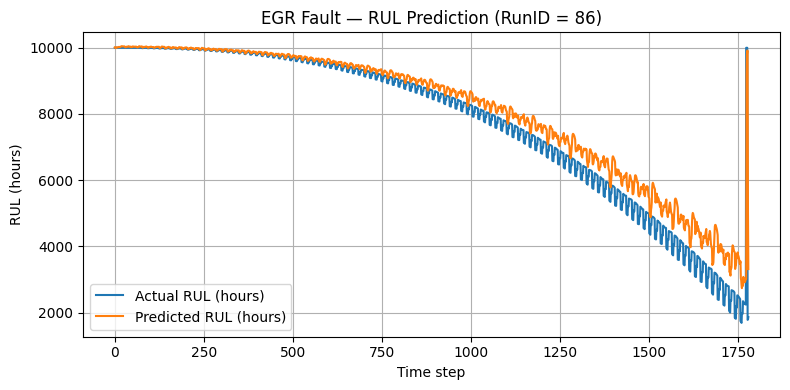

In [ ]:
import matplotlib.pyplot as plt

y_test_hours = scaler_y.inverse_transform(y_test_seq.reshape(-1,1)).flatten()
y_pred_hours = scaler_y.inverse_transform(y_pred_norm.reshape(-1,1)).flatten()

example_run = np.unique(run_ids_test_seq)[0]
mask = run_ids_test_seq == example_run

plt.figure(figsize=(8,4))
plt.plot(y_test_hours[mask], label="Actual RUL (hours)")
plt.plot(y_pred_hours[mask], label="Predicted RUL (hours)")
plt.xlabel("Time step")
plt.ylabel("RUL (hours)")
plt.title(f"EGR Fault — RUL Prediction (RunID = {example_run})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


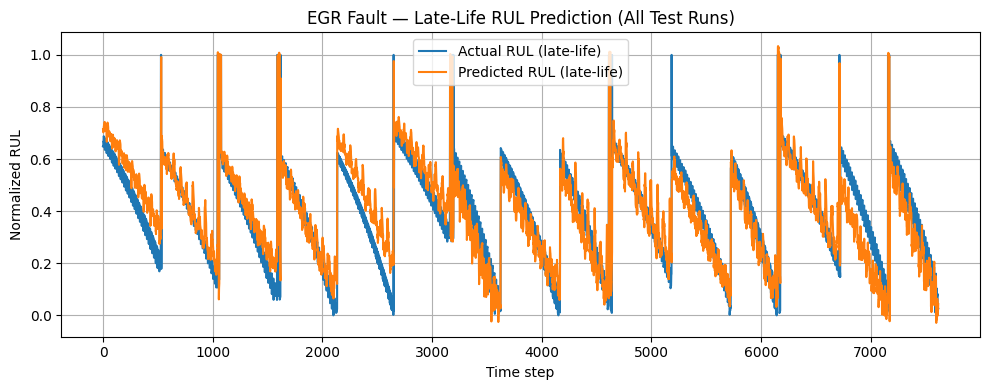

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(y_test_late, label="Actual RUL (late-life)")
plt.plot(y_pred_late, label="Predicted RUL (late-life)")
plt.xlabel("Time step")
plt.ylabel("Normalized RUL")
plt.title("EGR Fault — Late-Life RUL Prediction (All Test Runs)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


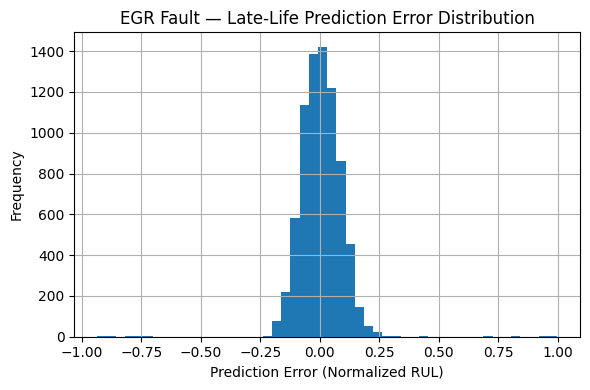

In [ ]:
errors = y_pred_late - y_test_late

plt.figure(figsize=(6,4))
plt.hist(errors, bins=50)
plt.xlabel("Prediction Error (Normalized RUL)")
plt.ylabel("Frequency")
plt.title("EGR Fault — Late-Life Prediction Error Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()


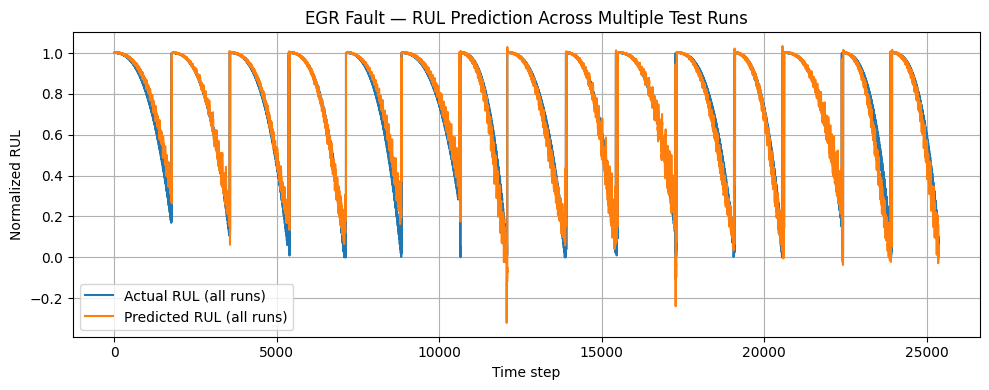

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(y_test_seq, label="Actual RUL (all runs)")
plt.plot(y_pred_norm, label="Predicted RUL (all runs)")
plt.xlabel("Time step")
plt.ylabel("Normalized RUL")
plt.title("EGR Fault — RUL Prediction Across Multiple Test Runs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## EGR Fault — Leakage-Free RUL Prediction Results and Interpretation

This section presents the Remaining Useful Life (RUL) prediction results for the
EGR (Exhaust Gas Recirculation) fault using a strictly leakage-free LSTM-based
framework. Only measurable operating signals (RPM and an EGR-related fault metric)
were used as inputs, while all damage-based, future-derived, and target-dependent
variables were excluded to ensure a realistic prognostics setup.

---

### Overall Prediction Performance

After converting normalized RUL predictions to absolute time using the initial
RUL of each run, the model achieved the following overall performance:

- **MAE:** ≈ **300.7 hours**
- **RMSE:** ≈ **604.3 hours**

These values indicate that, on average, the predicted remaining life deviates from
the true RUL by approximately 300 hours over the full operational lifespan. The
higher RMSE reflects the presence of larger deviations in a subset of samples,
which is expected in long-life degradation processes.

---

### Late-Life Prediction Performance

Late-life evaluation was performed on the final portion of each test trajectory,
where prognostic accuracy is most critical for maintenance decisions. The model
achieved:

- **Late-life MAE:** ≈ **643.4 hours**
- **Late-life RMSE:** ≈ **917.8 hours**

The increase in error magnitude during late life reflects accelerated degradation
and increased variability as failure approaches. For EGR systems, late-stage
behavior is influenced by soot buildup, valve sticking, and nonlinear exhaust flow
dynamics, which inherently limit prediction precision.

---

### Reliability Analysis (PW@α)

The Percentage Within Error (PW@α) metrics further characterize prediction reliability:

- **PW@0.05:** ≈ **46%**
- **PW@0.10:** ≈ **81%**
- **PW@0.20:** ≈ **99%**

These results indicate moderate precision at tight error thresholds, while
maintaining very high reliability at broader tolerances. This behavior suggests
that although fine-grained prediction is challenging for EGR degradation, the
model rarely produces catastrophic RUL estimation errors.

---

### Qualitative Analysis

Single-run and multi-run RUL plots demonstrate that the model consistently captures
the overall degradation trend across test trajectories. Increased prediction
variance is observed near failure, which is consistent with the stochastic nature
of EGR fault progression and load-dependent exhaust gas behavior.

The late-life error distribution is centered near zero but exhibits a wider spread
compared to other fault types, further reflecting the complex and nonlinear
dynamics associated with EGR degradation.

---

### Key Observations and Physical Interpretation

- EGR fault prognostics is inherently more challenging due to soot accumulation,
  valve dynamics, and nonlinear flow behavior.
- The leakage-free framework produces conservative and realistic error estimates.
- While late-life uncertainty is higher than for more deterministic faults, the
  model provides reliable trend-level RUL predictions suitable for maintenance
  planning.

---

### Summary

The results confirm that the proposed leakage-free LSTM framework delivers
meaningful and physically consistent RUL predictions for EGR faults. Although
absolute prediction errors increase near failure, the model maintains strong
reliability and avoids overconfident or misleading estimates, making it suitable
for practical prognostics applications involving EGR-related degradation.
